In [180]:
import numpy as np
import seaborn as sns
import pandas as pd
import matplotlib.pyplot as plt
import math
from sklearn.preprocessing import StandardScaler

In [160]:
df = pd.read_csv("../datasets_pc/diabetes.csv")
df.head()

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
0,6,148,72,35,0,33.6,0.627,50,1
1,1,85,66,29,0,26.6,0.351,31,0
2,8,183,64,0,0,23.3,0.672,32,1
3,1,89,66,23,94,28.1,0.167,21,0
4,0,137,40,35,168,43.1,2.288,33,1


In [161]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 768 entries, 0 to 767
Data columns (total 9 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   Pregnancies               768 non-null    int64  
 1   Glucose                   768 non-null    int64  
 2   BloodPressure             768 non-null    int64  
 3   SkinThickness             768 non-null    int64  
 4   Insulin                   768 non-null    int64  
 5   BMI                       768 non-null    float64
 6   DiabetesPedigreeFunction  768 non-null    float64
 7   Age                       768 non-null    int64  
 8   Outcome                   768 non-null    int64  
dtypes: float64(2), int64(7)
memory usage: 54.1 KB


In [162]:
df.isnull().sum()

Pregnancies                 0
Glucose                     0
BloodPressure               0
SkinThickness               0
Insulin                     0
BMI                         0
DiabetesPedigreeFunction    0
Age                         0
Outcome                     0
dtype: int64

In [163]:
df.describe()

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
count,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000
mean,3.845052,120.894531,69.105469,20.536458,79.799479,31.992578,0.471876,33.240885,0.348958
std,3.369578,31.972618,19.355807,15.952218,115.244002,7.884160,0.331329,11.760232,0.476951
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.078000,21.000000,0.000000
25%,1.000000,99.000000,62.000000,0.000000,0.000000,27.300000,0.243750,24.000000,0.000000
50%,3.000000,117.000000,72.000000,23.000000,30.500000,32.000000,0.372500,29.000000,0.000000
75%,6.000000,140.250000,80.000000,32.000000,127.250000,36.600000,0.626250,41.000000,1.000000
max,17.000000,199.000000,122.000000,99.000000,846.000000,67.100000,2.420000,81.000000,1.000000


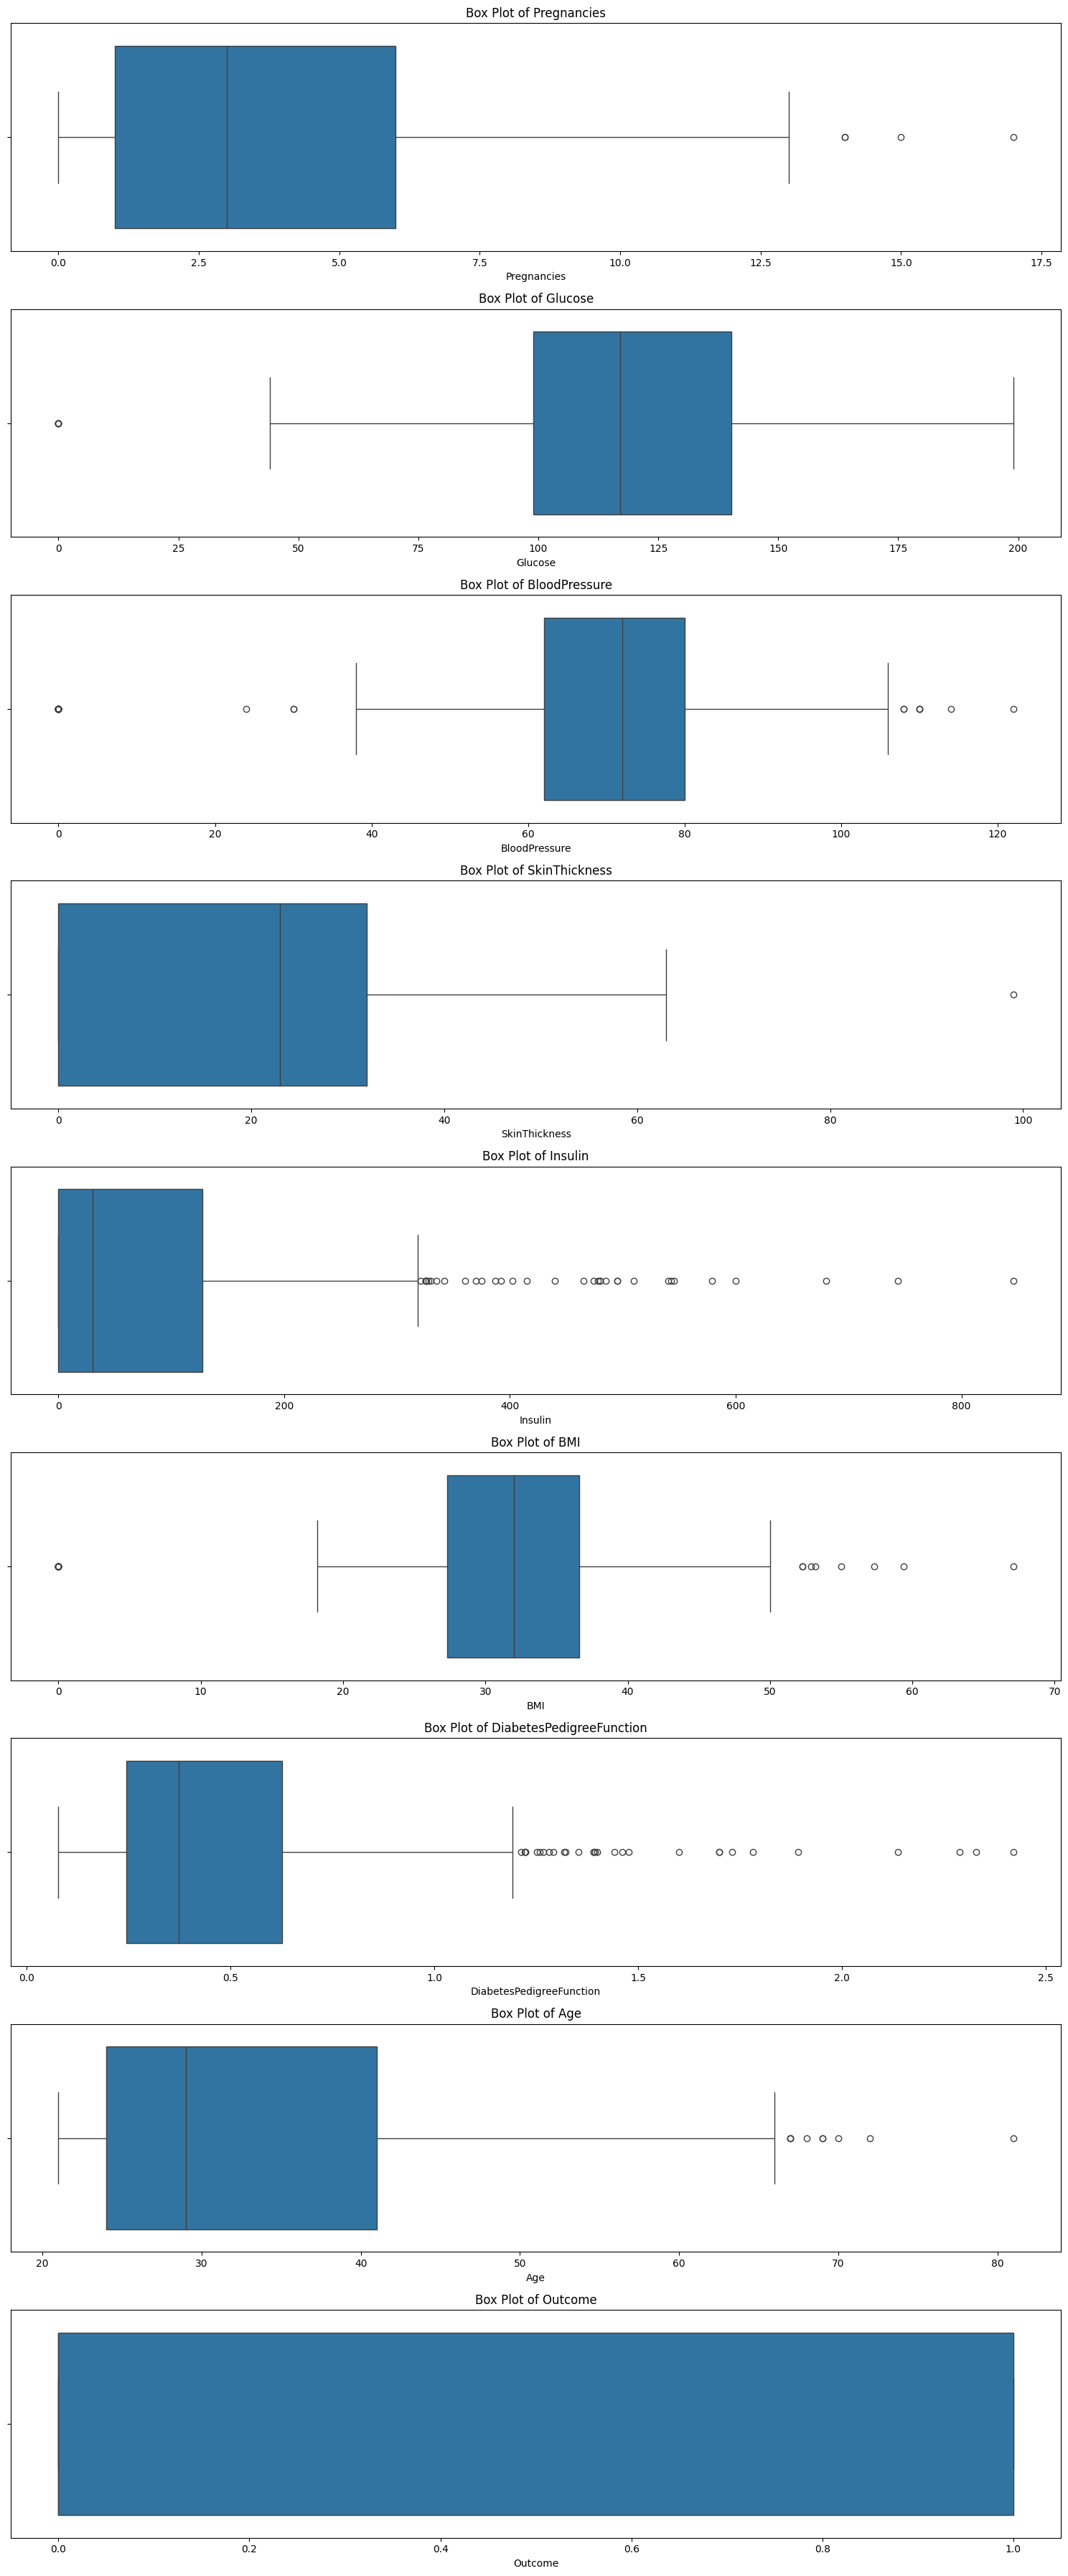

In [164]:
grid_cols = 1
grid_rows = math.ceil(len(df.columns)/grid_cols)

fig, axes = plt.subplots(grid_rows, grid_cols, figsize=(15, grid_rows*4))
axes = axes.flatten()

for i, col in enumerate(df.columns):
    sns.boxplot(data=df, x=col, ax=axes[i])
    axes[i].set_title(f"Box Plot of {col}")
    
plt.tight_layout()
plt.show()

<Axes: xlabel='Age', ylabel='Density'>

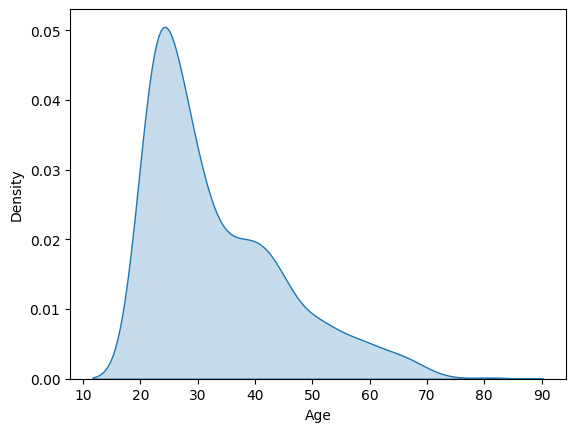

In [165]:
sns.kdeplot(df['Age'], fill=True)

In [166]:
mask = True
for col in df.columns:
    if col != "Outcome" and df[col].dtype != 'object':
        mean = df[col].mean()
        std = df[col].std()

        upper_bound = mean + 3 * std
        lower_bound = mean - 3 * std

        mask &= (df[col]>=lower_bound) & (df[col]<=upper_bound)
df = df[mask]

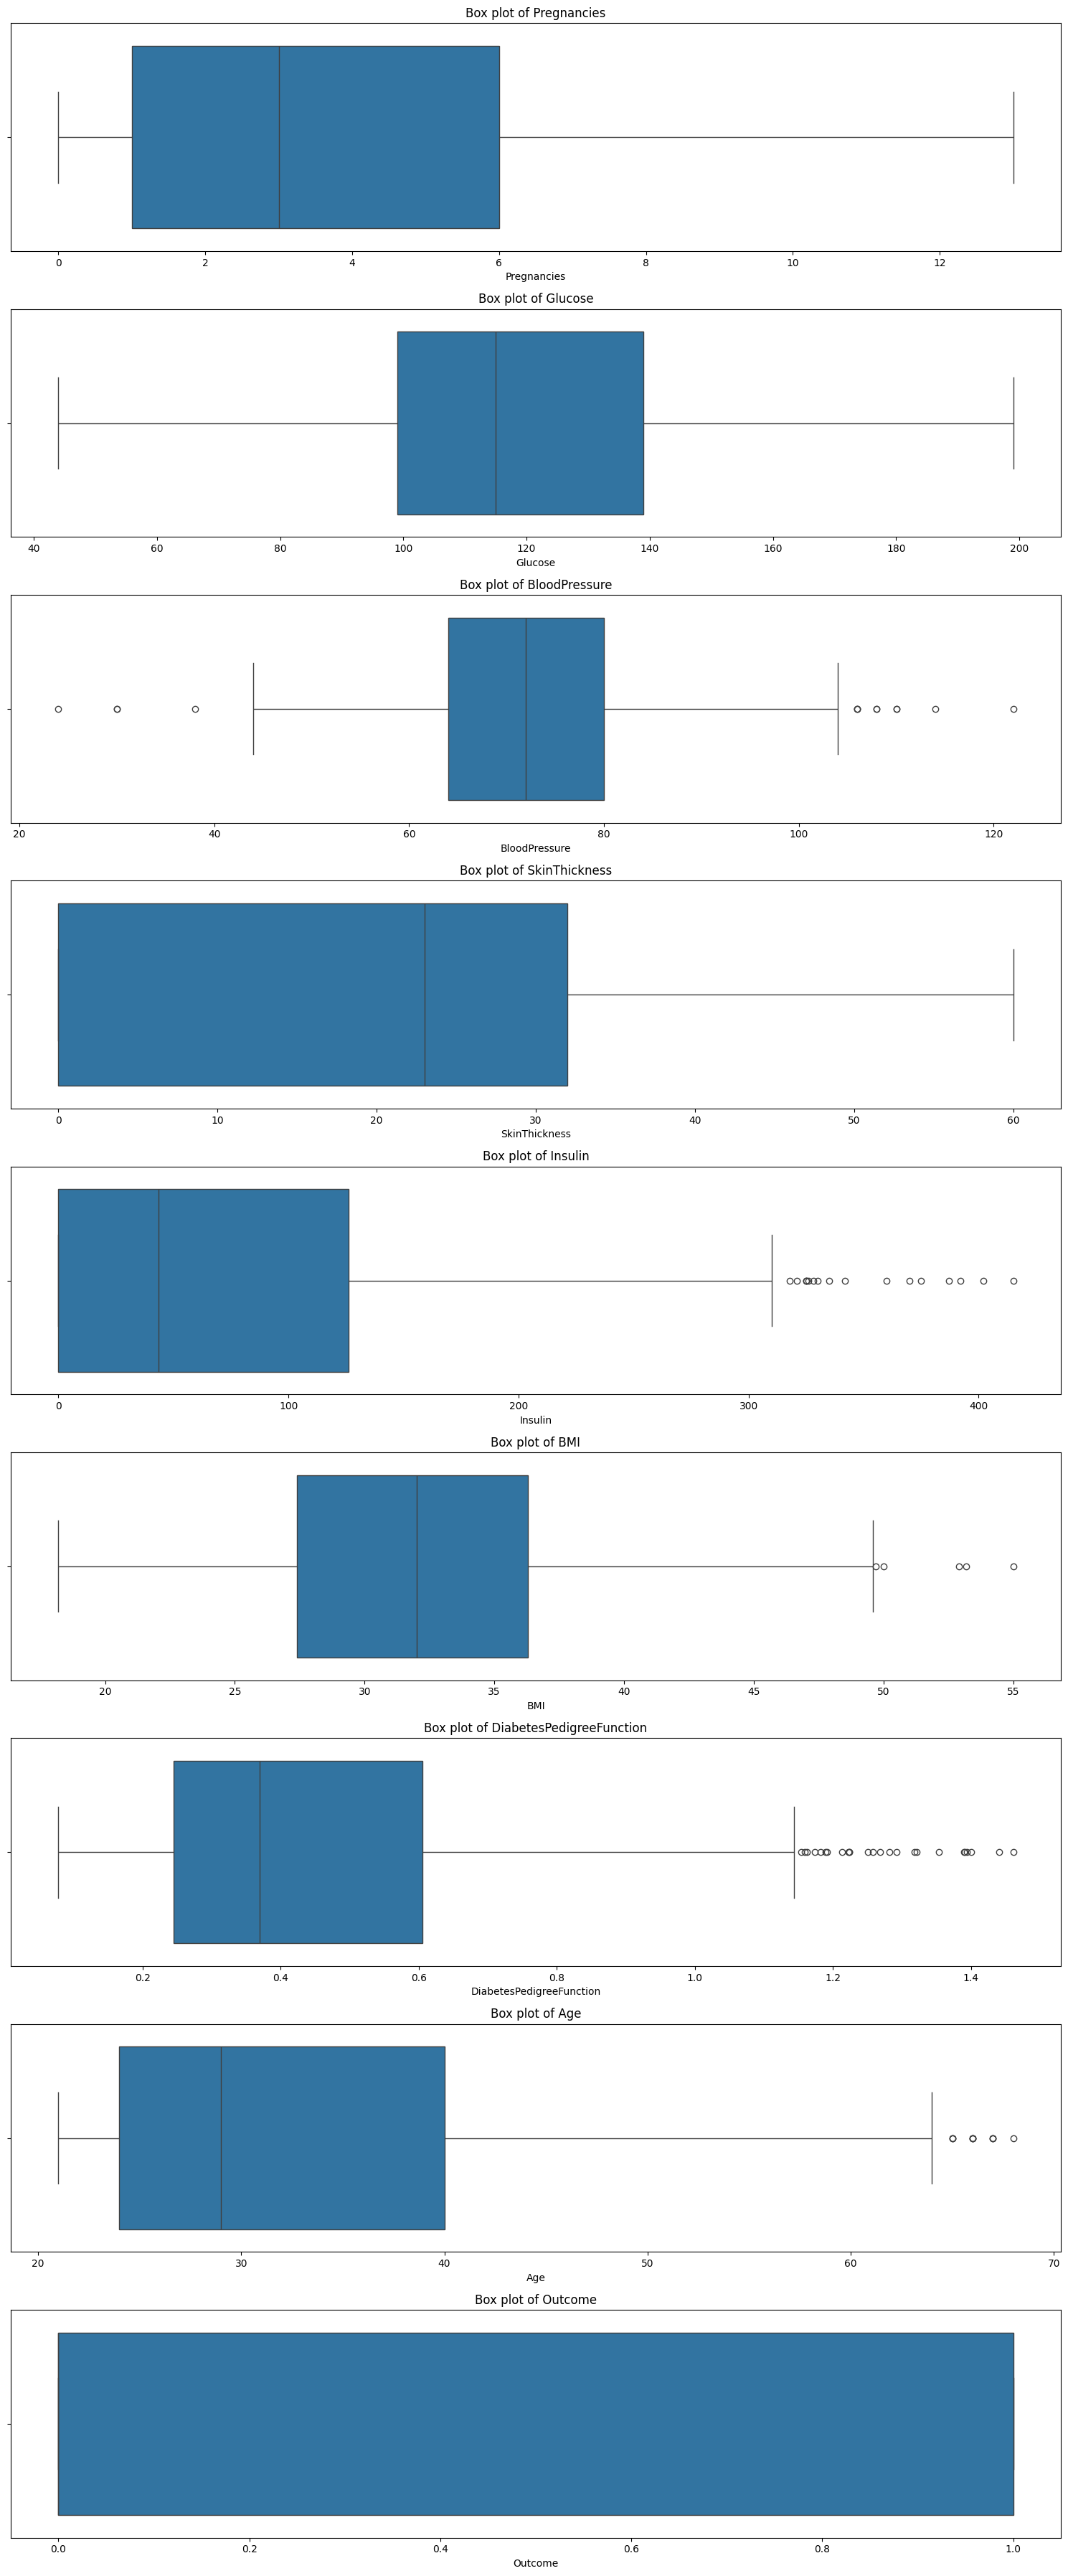

In [167]:
grid_cols = 1
grid_rows = math.ceil(len(df.columns)/grid_cols)

fig, axes = plt.subplots(grid_rows, grid_cols, figsize=(15, grid_rows*4))
axes = axes.flatten()

for i, col in enumerate(df.columns):
    sns.boxplot(data=df, x=col, ax=axes[i])
    axes[i].set_title(f"Box plot of {col}")

plt.tight_layout()
plt.show()

In [168]:
df.shape

(688, 9)

<Axes: >

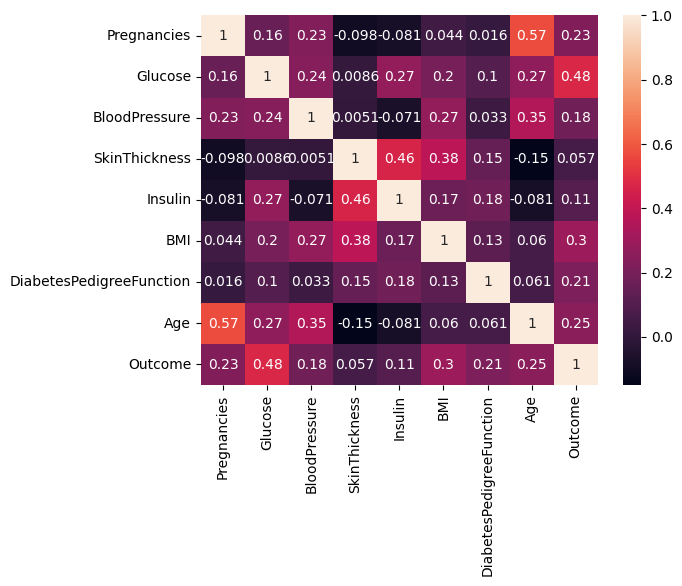

In [169]:
corr = df.corr()
sns.heatmap(data=corr, annot=True)

In [170]:
print(corr['Outcome'].sort_values(ascending=False))

Outcome                     1.000000
Glucose                     0.478614
BMI                         0.298056
Age                         0.246290
Pregnancies                 0.226382
DiabetesPedigreeFunction    0.213872
BloodPressure               0.182521
Insulin                     0.110062
SkinThickness               0.056662
Name: Outcome, dtype: float64


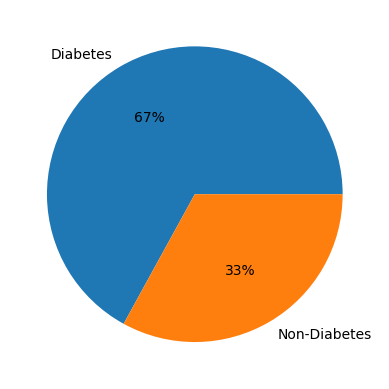

In [179]:
plt.pie(df['Outcome'].value_counts(), labels=['Diabetes', 'Non-Diabetes'], autopct="%.f%%")
plt.show()

In [186]:
X = df.drop(columns=['Outcome'])
y = df['Outcome']

In [189]:
scalar = StandardScaler()
X_scaled = scalar.fit_transform(X)

X_scaled

array([[ 0.65735547,  0.92404008, -0.02811548, ...,  0.21028523,
         0.60651604,  1.47921983],
       [-0.86848989, -1.17708222, -0.51576543, ..., -0.84806325,
        -0.36422044, -0.18326505],
       [ 1.26769361,  2.09133025, -0.67831541, ..., -1.34699896,
         0.76478829, -0.09576584],
       ...,
       [ 0.3521864 ,  0.0235591 , -0.02811548, ..., -0.90854031,
        -0.73703952, -0.27076425],
       [-0.86848989,  0.19031483, -1.00341538, ..., -0.31888901,
        -0.37125476,  1.21672222],
       [-0.86848989, -0.91027304, -0.19066546, ..., -0.27353122,
        -0.49083824, -0.88325868]])

<Axes: xlabel='Pregnancies', ylabel='Density'>

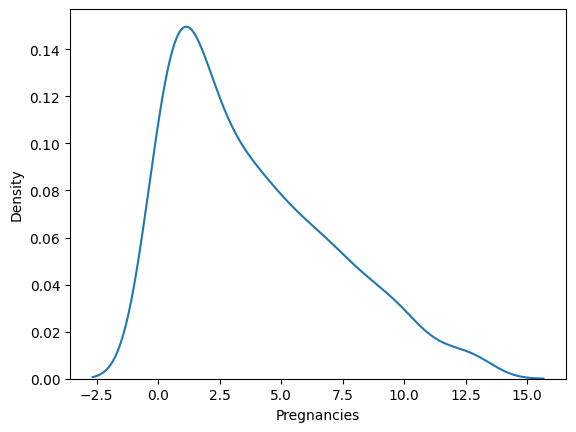

In [191]:
sns.kdeplot(df['Pregnancies'])

<Axes: ylabel='Density'>

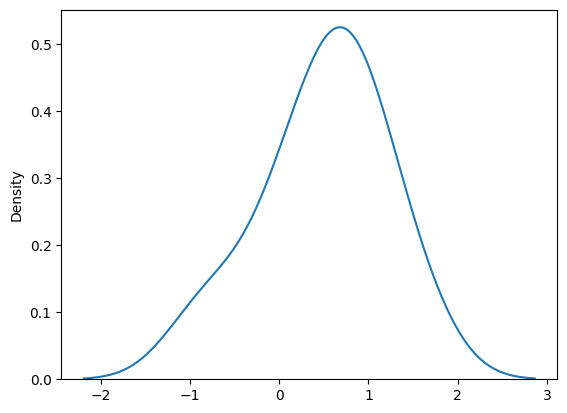

In [190]:
sns.kdeplot(X_scaled[0])